The objective of this notebook is to compare multiple machine learning and deep learning models for flood detection using SAR imagery. Three models—Random Forest, XGBoost, and Convolutional Neural Network (CNN)—are trained and evaluated using the same dataset. Their performance is compared based on Accuracy, F1-Score, Precision, Recall, and Training Time. The results help identify the most suitable model for deployment in the flood detection web dashboard and add research value to the project.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [3]:
FEATURE_DIR = "/content/drive/MyDrive/sar-project/data/features"
PROCESSED_DIR = "/content/drive/MyDrive/sar-project/data/processed"

In [4]:
#loading latent features
X_train_latent = np.load(
    os.path.join(FEATURE_DIR,
                 "latent_features_train.npy")
)
X_test_latent = np.load(
    os.path.join(FEATURE_DIR,
                 "latent_features_test.npy")
)
print(X_train_latent.shape)
print(X_test_latent.shape)

(356, 16384)
(90, 16384)


In [5]:
#loading images and masks
X_train = np.load(
    os.path.join(PROCESSED_DIR,
                 "X_train.npy")
)
X_test = np.load(
    os.path.join(PROCESSED_DIR,
                 "X_test.npy")
)
y_train = np.load(
    os.path.join(PROCESSED_DIR,
                 "y_train.npy")
)
y_test = np.load(
    os.path.join(PROCESSED_DIR,
                 "y_test.npy")
)

In [6]:
#convert masks to binary labels
y_train_cls = np.array([
    1 if np.sum(mask) > 0 else 0
    for mask in y_train
])
y_test_cls = np.array([
    1 if np.sum(mask) > 0 else 0
    for mask in y_test
])
print(np.unique(y_train_cls))
print(np.unique(y_test_cls))

[0 1]
[0 1]


In [7]:
#create results dictionary
results = []

In [8]:
#RANDOM FOREST
start_time = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(
    X_train_latent,
    y_train_cls
)
rf_time = time.time() - start_time

In [9]:
rf_pred = rf.predict(
    X_test_latent
)
rf_accuracy = accuracy_score(
    y_test_cls,
    rf_pred
)
rf_precision = precision_score(
    y_test_cls,
    rf_pred
)
rf_recall = recall_score(
    y_test_cls,
    rf_pred
)
rf_f1 = f1_score(
    y_test_cls,
    rf_pred
)
results.append([
    "Random Forest",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_time
])
print("RF Accuracy:", rf_accuracy)

RF Accuracy: 0.8777777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
#XGBOOST
start_time = time.time()
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(
    X_train_latent,
    y_train_cls
)
xgb_time = time.time() - start_time

In [11]:
xgb_pred = xgb.predict(
    X_test_latent
)
xgb_accuracy = accuracy_score(
    y_test_cls,
    xgb_pred
)
xgb_precision = precision_score(
    y_test_cls,
    xgb_pred
)
xgb_recall = recall_score(
    y_test_cls,
    xgb_pred
)
xgb_f1 = f1_score(
    y_test_cls,
    xgb_pred
)
results.append([
    "XGBoost",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_time
])
print("XGB Accuracy:", xgb_accuracy)

XGB Accuracy: 0.9


In [12]:
#CNN CLASSIFIER
cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu' ),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
start_time = time.time()

history = cnn.fit(
    X_train,
    y_train_cls,
    validation_data=(
        X_test,
        y_test_cls
    ),
    epochs=10,
    batch_size=16,
    verbose=1
)
cnn_time = time.time() - start_time

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 488ms/step - accuracy: 0.8539 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 497ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 472ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 452ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 469ms/step - accuracy: 0.8736 - loss: nan - val_accuracy: 0.8778 - val_loss: nan
Epoch 9/10
23/23 

In [15]:
cnn_prob = cnn.predict(
    X_test
)
cnn_pred = (
    cnn_prob > 0.5
).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step


In [16]:
cnn_accuracy = accuracy_score(
    y_test_cls,
    cnn_pred
)
cnn_precision = precision_score(
    y_test_cls,
    cnn_pred
)
cnn_recall = recall_score(
    y_test_cls,
    cnn_pred
)
cnn_f1 = f1_score(
    y_test_cls,
    cnn_pred
)
results.append([
    "CNN",
    cnn_accuracy,
    cnn_precision,
    cnn_recall,
    cnn_f1,
    cnn_time
])
print("CNN Accuracy:", cnn_accuracy)

CNN Accuracy: 0.8777777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
#RESULTS
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)"
    ]
)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Random Forest,0.877778,0.00,0.000000,0.0,2.670678
1,XGBoost,0.900000,0.75,0.272727,0.4,92.562242
2,CNN,0.877778,0.00,0.000000,0.0,118.221257


In [18]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
1,XGBoost,0.900000,0.75,0.272727,0.4,92.562242
0,Random Forest,0.877778,0.00,0.000000,0.0,2.670678
2,CNN,0.877778,0.00,0.000000,0.0,118.221257


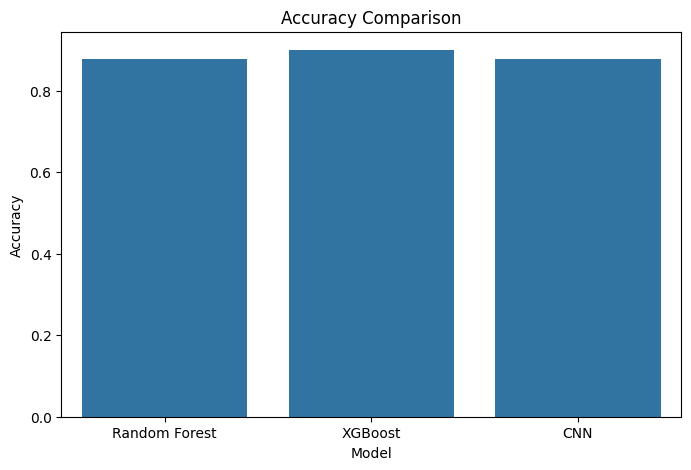

In [19]:
#ACCURACY COMPARISION
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Accuracy Comparison"
)

plt.show()

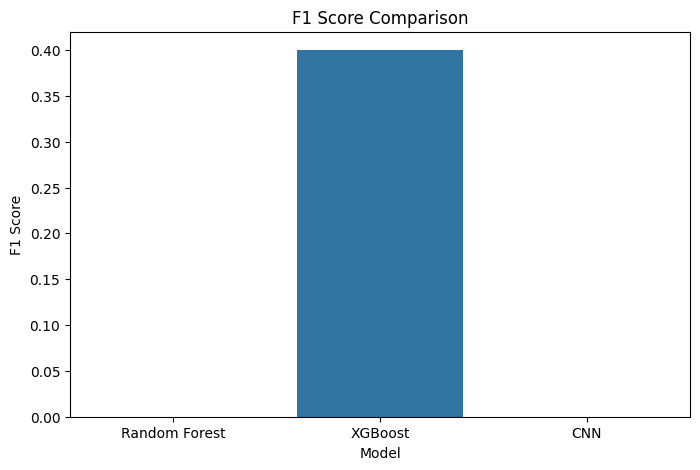

In [20]:
#F1 SCORE COMPARISION
plt.figure(figsize=(8,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)
plt.title(
    "F1 Score Comparison"
)
plt.show()

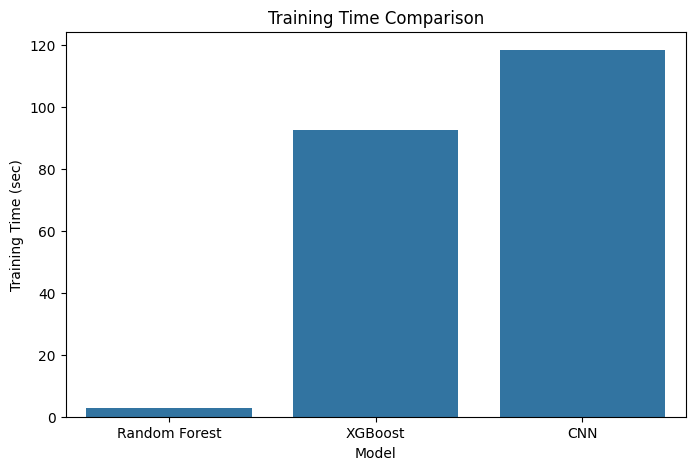

In [21]:
#TRAINING TIME COMPARISION
plt.figure(figsize=(8,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Training Time (sec)"
)
plt.title(
    "Training Time Comparison"
)
plt.show()

In [22]:
#saving comparision results
results_df.to_csv(
    "/content/drive/MyDrive/sar-project/model_comparison_results.csv",
    index=False
)
print(
    "Comparison Results Saved"
)

Comparison Results Saved


In [23]:
#final analysis
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]
print("Best Model")
print(best_model)

Best Model
Model                    XGBoost
Accuracy                     0.9
Precision                   0.75
Recall                  0.272727
F1 Score                     0.4
Training Time (sec)    92.562242
Name: 1, dtype: object
